![step1.png](attachment:step1.png)

In [81]:
import pandas as pd

df = pd.read_csv("laptopData.csv")
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()


# Data before cleaning

In [88]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1243 entries, 0 to 1273
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1243 non-null   object 
 1   TypeName          1243 non-null   object 
 2   Inches            1242 non-null   object 
 3   ScreenResolution  1243 non-null   object 
 4   Cpu               1243 non-null   object 
 5   Ram               1243 non-null   float64
 6   Memory            1242 non-null   object 
 7   Gpu               1243 non-null   object 
 8   OpSys             1243 non-null   object 
 9   Weight            1243 non-null   float64
 10  Price             1243 non-null   float64
dtypes: float64(3), object(8)
memory usage: 116.5+ KB


The dataset contains missing values and some columns stored in incorrect formats. Additionally, an unnecessary column (Unnamed: 0) is present.

### Check Missing Values

In [89]:
# Check all values
print(df.isna())

      Company  TypeName  Inches  ScreenResolution    Cpu    Ram  Memory  \
0       False     False   False             False  False  False   False   
1       False     False   False             False  False  False   False   
2       False     False   False             False  False  False   False   
3       False     False   False             False  False  False   False   
4       False     False   False             False  False  False   False   
...       ...       ...     ...               ...    ...    ...     ...   
1269    False     False   False             False  False  False   False   
1270    False     False   False             False  False  False   False   
1271    False     False   False             False  False  False   False   
1272    False     False   False             False  False  False   False   
1273    False     False   False             False  False  False   False   

        Gpu  OpSys  Weight  Price  
0     False  False   False  False  
1     False  False   False 

In [90]:
print(df.isna().sum())

Company             0
TypeName            0
Inches              1
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              1
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64


### Check duplicate rows

In [91]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0


### No. of rows and columns

In [92]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (1243, 11) 

number of rows:  1243
number of columns:  11


### Data type of columns

In [93]:
# viewing the data types of columns
df.dtypes

,0
Company,object
TypeName,object
Inches,object
ScreenResolution,object
Cpu,object
Ram,float64
Memory,object
Gpu,object
OpSys,object
Weight,float64


In [95]:
df = df.drop('Unnamed: 0', axis=1, errors='ignore')

df['Ram'] = df['Ram'].astype(str).str.replace('GB', '', regex=False)
df['Ram'] = pd.to_numeric(df['Ram'], errors='coerce')

df['Weight'] = df['Weight'].astype(str).str.replace('kg', '', regex=False)
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df = df.dropna()
df = df.drop_duplicates()

df = df.replace('?', None)

df.dtypes

,0
Company,object
TypeName,object
Inches,object
ScreenResolution,object
Cpu,object
Ram,float64
Memory,object
Gpu,object
OpSys,object
Weight,float64


The dataset required several cleaning steps before analysis. Missing values were found in multiple columns and were removed to ensure data consistency. Duplicate rows were also identified and deleted to avoid biased results. Additionally, some columns such as Ram and Weight contained text with units (GB and kg), which were converted into numeric format to allow proper analysis and visualization.

# Data to run after cleaning

In [96]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1241 entries, 0 to 1273
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1241 non-null   object 
 1   TypeName          1241 non-null   object 
 2   Inches            1241 non-null   object 
 3   ScreenResolution  1241 non-null   object 
 4   Cpu               1241 non-null   object 
 5   Ram               1241 non-null   float64
 6   Memory            1241 non-null   object 
 7   Gpu               1241 non-null   object 
 8   OpSys             1241 non-null   object 
 9   Weight            1241 non-null   float64
 10  Price             1241 non-null   float64
dtypes: float64(3), object(8)
memory usage: 116.3+ KB


The dataset became cleaner after removing missing values and duplicate rows. The unnecessary column was removed, and columns such as RAM and Weight were converted into numeric format. The number of rows decreased, indicating that incomplete or duplicate data was successfully removed.

In [97]:
# Statistical summary
df.describe(include='all')

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
count,1241,1241,1241,1241,1241,1241.000000,1241,1241,1241,1241.000000,1241.000000
unique,19,6,24,40,118,NaN,39,110,9,NaN,NaN
top,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,NaN,256GB SSD,Intel HD Graphics 620,Windows 10,NaN,NaN
freq,282,688,620,490,183,NaN,399,269,1019,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,8.522965,NaN,NaN,NaN,2.080298,60536.425594
std,NaN,NaN,NaN,NaN,NaN,5.589564,NaN,NaN,NaN,0.814657,37417.445472
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.000200,9270.720000
25%,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,1.500000,32639.860800
50%,NaN,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,NaN,2.040000,52693.920000
75%,NaN,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,NaN,2.330000,79813.440000


### Descriptive summary Statistics

### Univariate Analysis

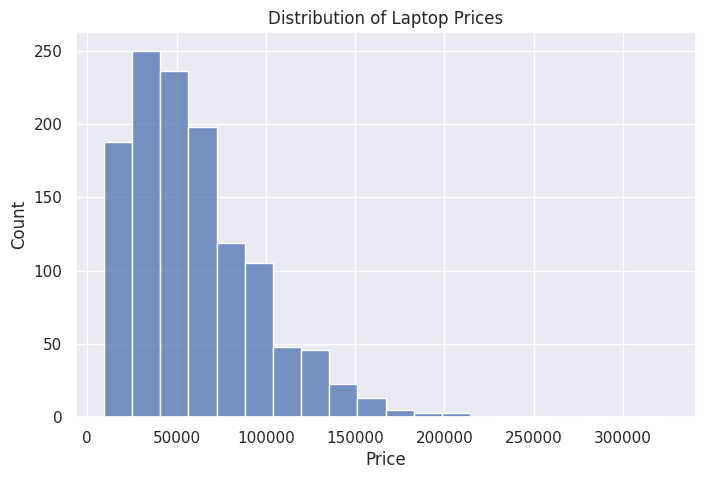

In [98]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=20)
plt.title("Distribution of Laptop Prices")
plt.show()

Shows how laptop prices are distributed.

Right skew = many low-priced laptops and a few very expensive ones.

## Bivariate Analysis

### Price by company

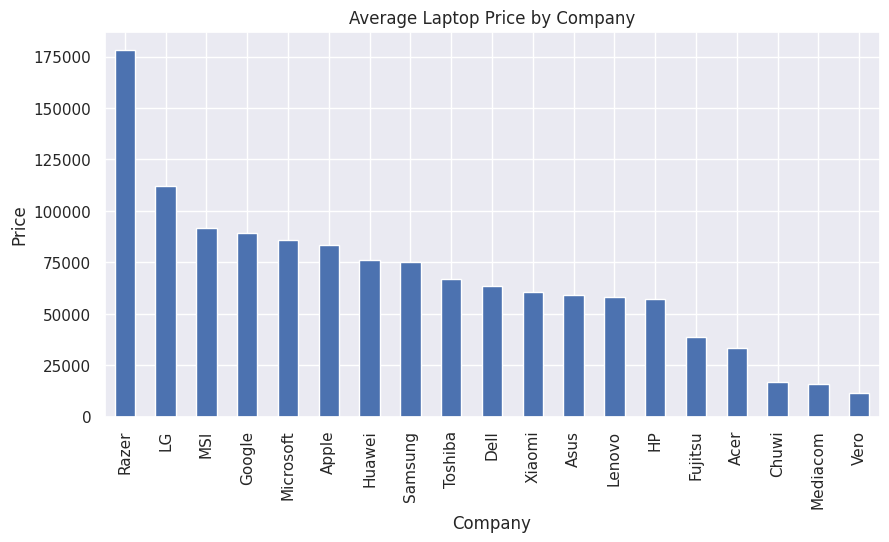

,Price
Company,
Razer,178282.491429
LG,111834.720000
MSI,91814.548891
Google,89386.080000
Microsoft,85903.788000
Apple,83340.499886
Huawei,75870.720000
Samsung,75308.320000
Toshiba,66747.370213


In [ ]:
company_price = df.groupby('Company')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
company_price.plot(kind='bar')
plt.title("Average Laptop Price by Company")
plt.ylabel("Price")
plt.show()

company_price

This chart shows the average laptop price for each company. It helps compare pricing strategies between different brands. We can observe that some companies tend to produce higher-priced laptops, while others focus on more affordable options.

###  Price by laptop type

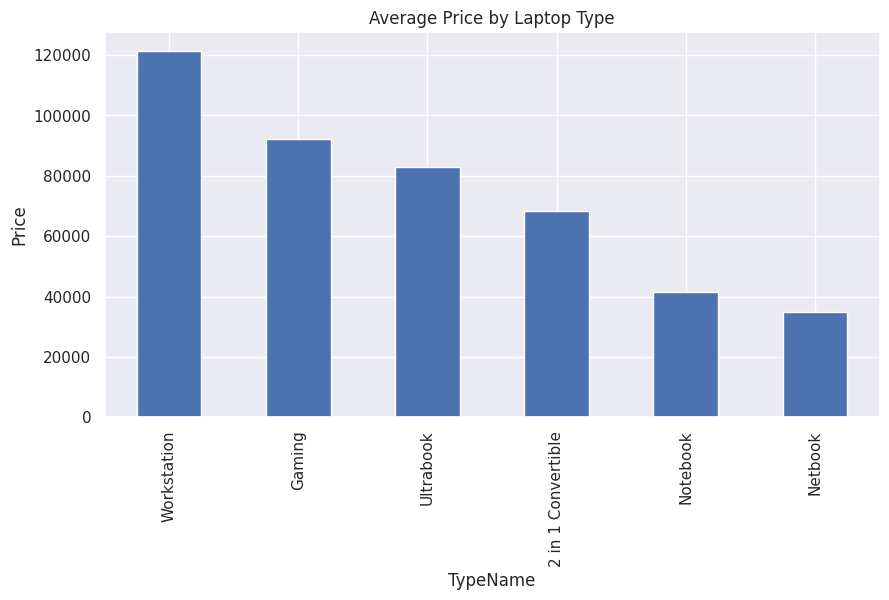

,Price
TypeName,
Workstation,121497.525683
Gaming,92204.328662
Ultrabook,82926.038073
2 in 1 Convertible,68186.738110
Notebook,41545.173052
Netbook,34884.858000


In [ ]:
type_price = df.groupby('TypeName')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
type_price.plot(kind='bar')
plt.title("Average Price by Laptop Type")
plt.ylabel("Price")
plt.show()

type_price

Shows the average price by laptop type

Workstations are the most expensive
Netbooks and notebooks are the least expensive

### Price by operating system

In [ ]:
opsys_price = df.groupby('OpSys')['Price'].mean().sort_values(ascending=False)

opsys_price.head(10)

,Price
OpSys,
macOS,93220.327385
Windows 7,89864.783040
Windows 10 S,68543.654400
Mac OS X,67285.780200
Windows 10,62214.308452
Linux,32919.414846
No OS,31892.934400
Chrome OS,29495.018667
Android,29250.720000


### RAM vs Price

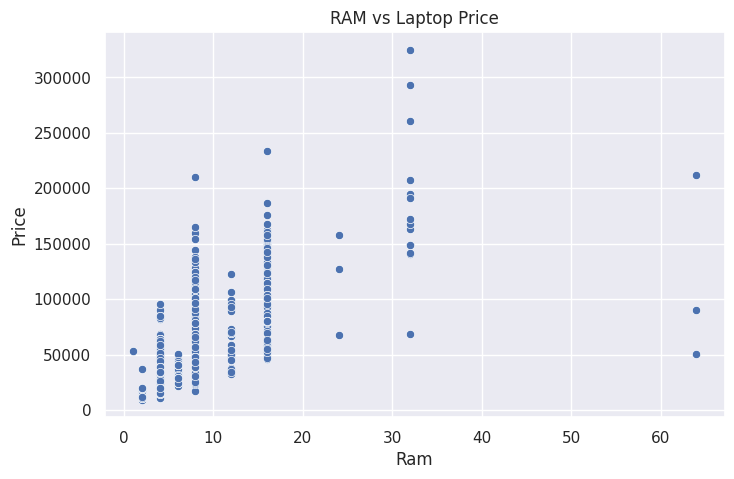

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Ram', y='Price', data=df)
plt.title("RAM vs Laptop Price")
plt.show()

Shows the relationship between RAM and laptop price

Higher RAM = higher price

### Weight vs Price

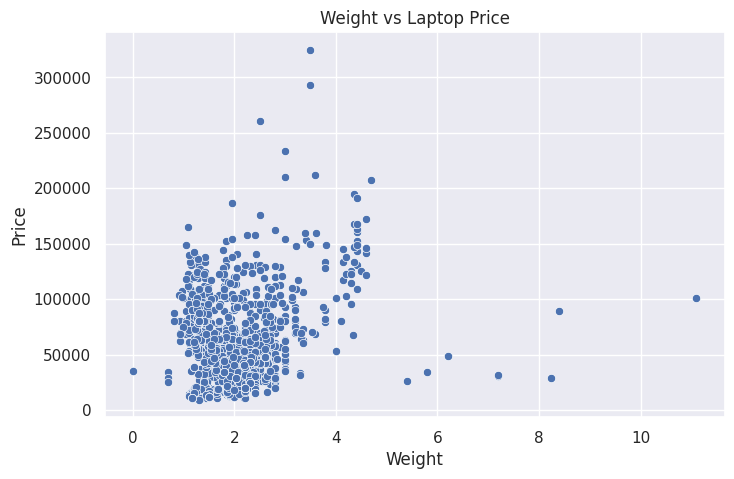

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Weight', y='Price', data=df)
plt.title("Weight vs Laptop Price")
plt.show()

Shows the relationship between RAM and laptop price

Higher RAM = higher price

### Correlation Matrix

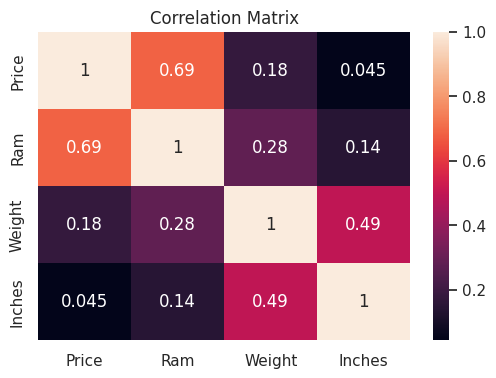

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Price', 'Ram', 'Weight', 'Inches']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

Correlation close to 1 = strong relationship

Correlation close to 0 = weak relationship

Price and RAM show strong correlation

Weight and Inches show moderate correlation

### Average Price by Company

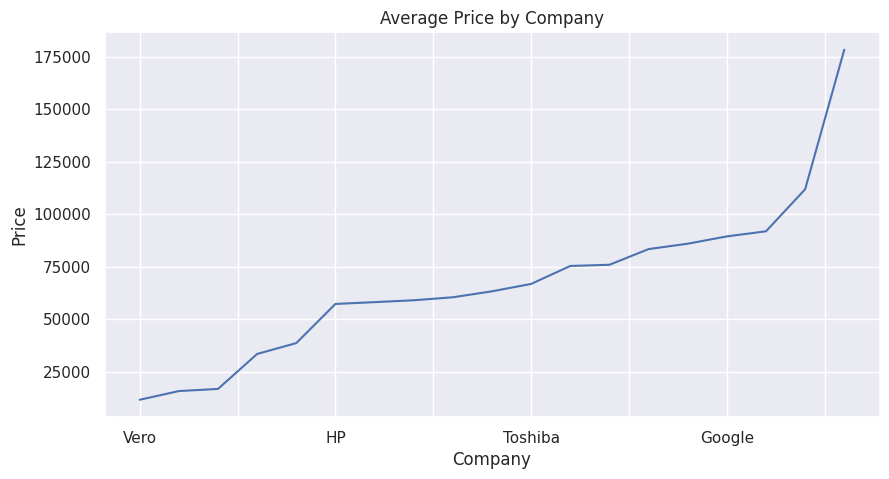

In [ ]:
company_price = df.groupby('Company')['Price'].mean().sort_values()

plt.figure(figsize=(10,5))
company_price.plot()
plt.title("Average Price by Company")
plt.ylabel("Price")
plt.show()

Shows the average price by company

Some companies have higher prices
Others offer more affordable laptops

I used different types of visualizations to better understand the data. Histograms helped me see how values are distributed, bar charts helped compare categories like companies and laptop types, scatter plots showed relationships between variables such as RAM and price, and heatmaps helped identify correlations between numerical features.

# Insights

especially RAM, where laptops with higher RAM usually have higher prices. There are also noticeable differences between laptop types and companies, as some brands focus on high-end and expensive devices, while others offer more affordable options. In addition, most laptops have similar weights, which means weight does not vary as much as other features.

From these results, we can understand that technical specifications have a strong impact on laptop prices, and some features are more important than others. This is useful in artificial intelligence, since this kind of data can be used later to build models such as price prediction or recommendation systems based on laptop specifications.